# Project Code

# **Part 1-Data Exploration (exploratory data analysis or EDA)**

In [ ]:
# Regular EDA and plotting libraries
import numpy as np # np is short for numpy

import pandas as pd # pandas is so commonly used, it's shortened to pd

import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns # seaborn gets shortened to sns, TK - can seaborn be removed for matplotlib (simpler)?

## Models
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
# from sklearn.metrics import plot_roc_curve # note: this was changed in Scikit-Learn 1.2+ to be "RocCurveDisplay" (see below)
from sklearn.metrics import RocCurveDisplay # new in Scikit-Learn 1.2+

# Print last updated
import datetime
print(f"Notebook last updated: {datetime.datetime.now()}\n")

# Print versions of libraries we're using (as long as yours are equal or greater than these, your code should work)
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

Notebook last updated: 2026-05-04 06:23:53.232096

NumPy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
Scikit-Learn version: 1.6.1


In [ ]:
df = pd.read_csv('cardio_train.csv', sep=';')
df.shape

(70000, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


Here are all 13 features in your dataset:

1-id — just a unique number for each patient, no medical meaning

2-age — patient's age (originally in days, we converted it to years)

3-gender — 1 = female, 2 = male

4-height — height in cm

5-weight — weight in kg

6-ap_hi — systolic blood pressure (top number, e.g. 120 in 120/80)
ap_hi = Systolic blood pressure — the top number when you measure blood pressure (e.g. the 120 in 120/80). It measures pressure when your heart beats.

7-ap_lo — diastolic blood pressure (bottom number, e.g. 80 in 120/80)
ap_lo = Diastolic blood pressure — the bottom number (e.g. the 80 in 120/80). It measures pressure when your heart rests between beats.

8-cholesterol — 1 = normal, 2 = above normal, 3 = well above normal

9-gluc — glucose level: 1 = normal, 2 = above normal, 3 = well above normal

10-smoke — does the patient smoke? 0 = no, 1 = yes

11-alco — does the patient drink alcohol? 0 = no, 1 = yes

12-active — is the patient physically active? 0 = no, 1 = yes

13-cardio — d

In [ ]:
df.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
df['age'] = (df['age'] / 365).round(1)

In [ ]:
df.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.4,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55.4,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51.7,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48.3,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47.9,1,156,56.0,100,60,1,1,0,0,0,0


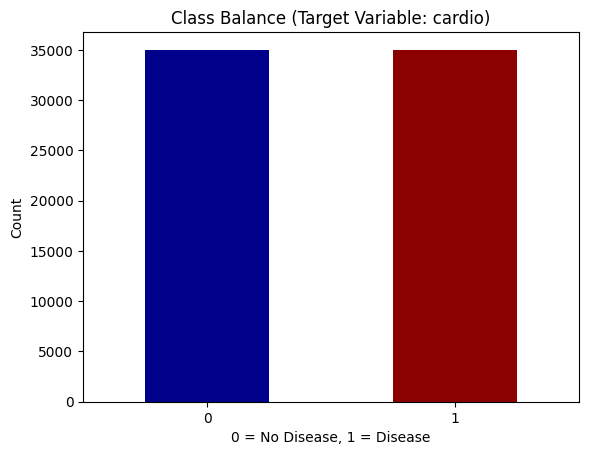

cardio
0    35021
1    34979
Name: count, dtype: int64
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


In [ ]:
# Check class balance visually
df['cardio'].value_counts().plot(kind='bar', color=['darkblue', 'darkred'])
plt.title('Class Balance (Target Variable: cardio)')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Also print the exact numbers
print(df['cardio'].value_counts())
print(df['cardio'].value_counts(normalize=True) * 100)  # shows percentages

Binary classification
This is a binary classification problem. Our goal is to predict one of two outcomes for each patient — either they have cardiovascular disease or they do not. Classification is used when the output is a category (a label), not a continuous number. Since there are exactly two possible labels (0 = no disease, 1 = disease), it is specifically binary classification.
Binary classification Supervised learning Not regression


In [ ]:
# This is a classification problem, not regression.
# We are predicting a category (0 or 1), not a number.
# Binary classification: two possible outcomes
#   0 = No cardiovascular disease
#   1 = Has cardiovascular disease

print("Problem type: Binary Classification")
print("Target variable: cardio (0 = No Disease, 1 = Disease)")
print("Number of classes:", df['cardio'].nunique())

What we are trying to achieve
The ultimate goal of this project is to build a machine learning model that can accurately predict whether a patient has cardiovascular disease based on basic health measurements. If successful, such a model could assist doctors by flagging high-risk patients early — before symptoms appear — allowing for preventive treatment. In the real world, this could reduce the number of undiagnosed cases and help prioritize patients who need further medical tests.


Ultimate goal of this project:
Train a model that predicts cardiovascular disease (cardio = 0 or 1)
from 11 patient health features.

If this model works well, it could:
1. Flag high-risk patients before symptoms appear
2. Help doctors prioritize who needs further testing
3. Support preventive treatment decisions

We measure success using: accuracy, precision, recall, and F1 score

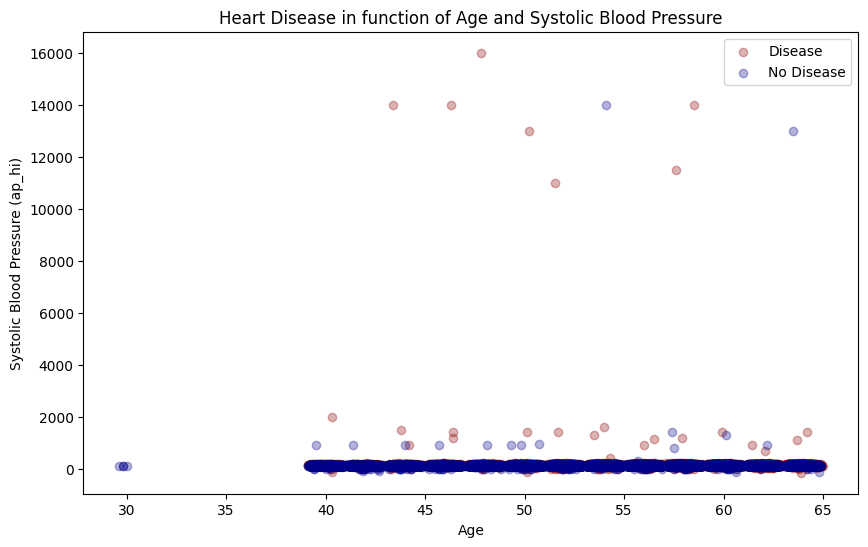

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(df.age[df.cardio==1],
            df.ap_hi[df.cardio==1],
            c="darkred", alpha=0.3)

plt.scatter(df.age[df.cardio==0],
            df.ap_hi[df.cardio==0],
            c="darkblue", alpha=0.3)

plt.title("Heart Disease in function of Age and Systolic Blood Pressure")
plt.xlabel("Age")
plt.ylabel("Systolic Blood Pressure (ap_hi)")
plt.legend(["Disease", "No Disease"]);

In this step, we are looking at how age and blood pressure are related to heart disease. Our dataset has 70,000 patients. Before making the plot, we cleaned the data by removing some bad values, for example, some blood pressure readings were way too high (like 16,000!) which are clearly mistakes. Normal blood pressure should be between 70–200, so we removed anything outside that range. After cleaning, we made a scatter plot where each dot is one patient. Dark red dots are patients who have heart disease and dark blue dots are patients who don't. This helps us see if older people or people with higher blood pressure are more likely to get heart disease.

In [ ]:
# Remove outliers - keep only realistic blood pressure values
df = df[(df['ap_hi'] >= 70) & (df['ap_hi'] <= 200)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 140)]  # clean ap_lo too while we're at it

print(df.shape)  # check how many rows remain


(68696, 13)


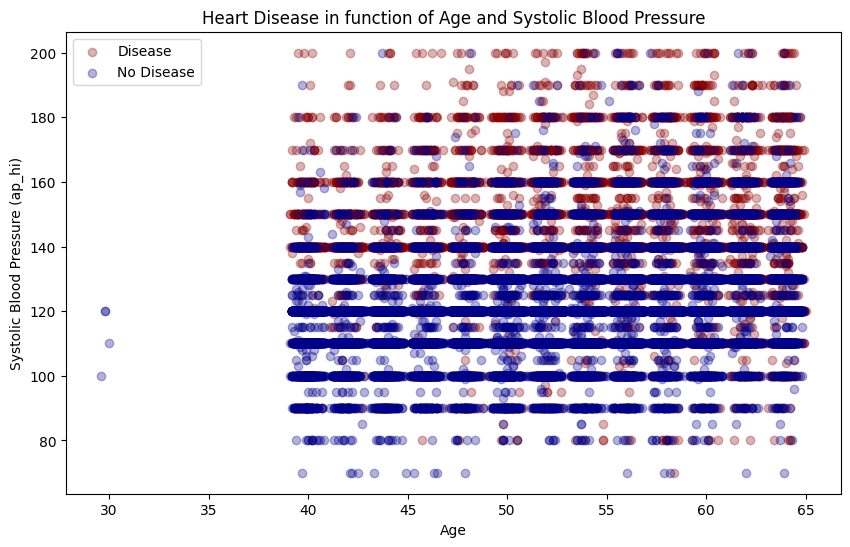

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(df.age[df.cardio==1],
            df.ap_hi[df.cardio==1],
            c="darkred", alpha=0.3)

plt.scatter(df.age[df.cardio==0],
            df.ap_hi[df.cardio==0],
            c="darkblue", alpha=0.3)

plt.title("Heart Disease in function of Age and Systolic Blood Pressure")
plt.xlabel("Age")
plt.ylabel("Systolic Blood Pressure (ap_hi)")
plt.legend(["Disease", "No Disease"]);

From the plot we can see a few things:

Most patients are between 39 and 65 years old
People with heart disease (dark red) tend to have higher blood pressure, mostly above 140
People without heart disease (dark blue) are more spread in the lower blood pressure range, mostly below 130
The horizontal lines are because blood pressure is usually recorded in round numbers like 120, 130, 140 etc.

Overall the graph shows that higher blood pressure + older age = more chance of heart disease, which makes sense medically.

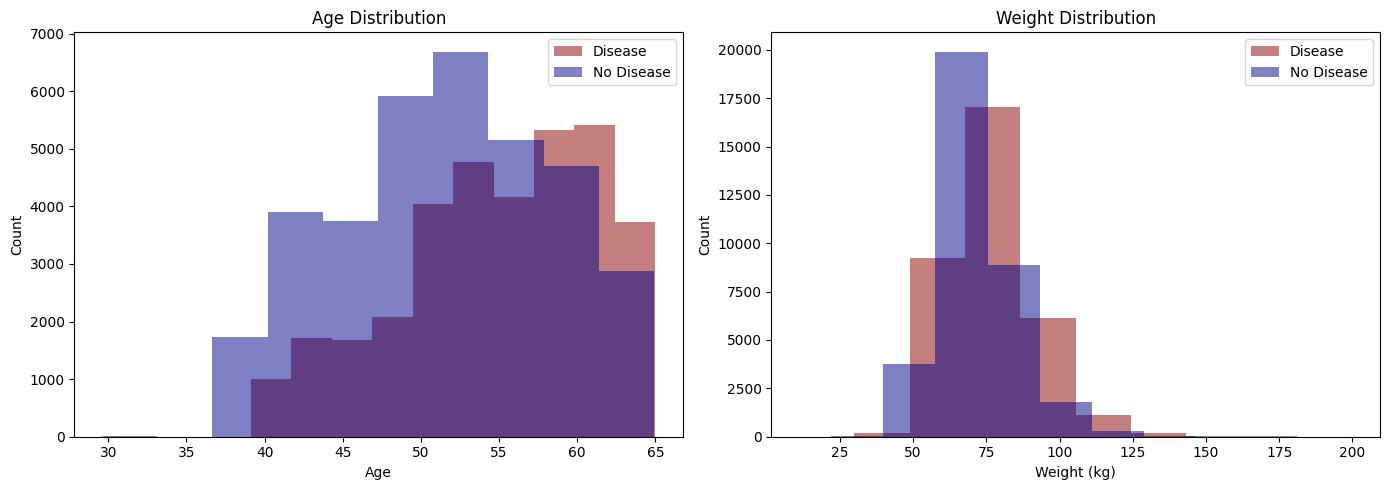

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram
axes[0].hist(df.age[df.cardio==1], color="darkred", alpha=0.5, label="Disease")
axes[0].hist(df.age[df.cardio==0], color="darkblue", alpha=0.5, label="No Disease")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

# Weight histogram
axes[1].hist(df.weight[df.cardio==1], color="darkred", alpha=0.5, label="Disease")
axes[1].hist(df.weight[df.cardio==0], color="darkblue", alpha=0.5, label="No Disease")
axes[1].set_title("Weight Distribution")
axes[1].set_xlabel("Weight (kg)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

Age:

Younger people (30–45) mostly do NOT have heart disease (more blue)

As age goes up past 50, the red starts to dominate — more disease cases

So the older you are, the higher the risk — which makes total sense

Weight:

People around 70–80kg have the most disease cases (red peaks there)

Very light people (under 50kg) rarely have heart disease

As weight goes up past 80kg, disease cases stay high

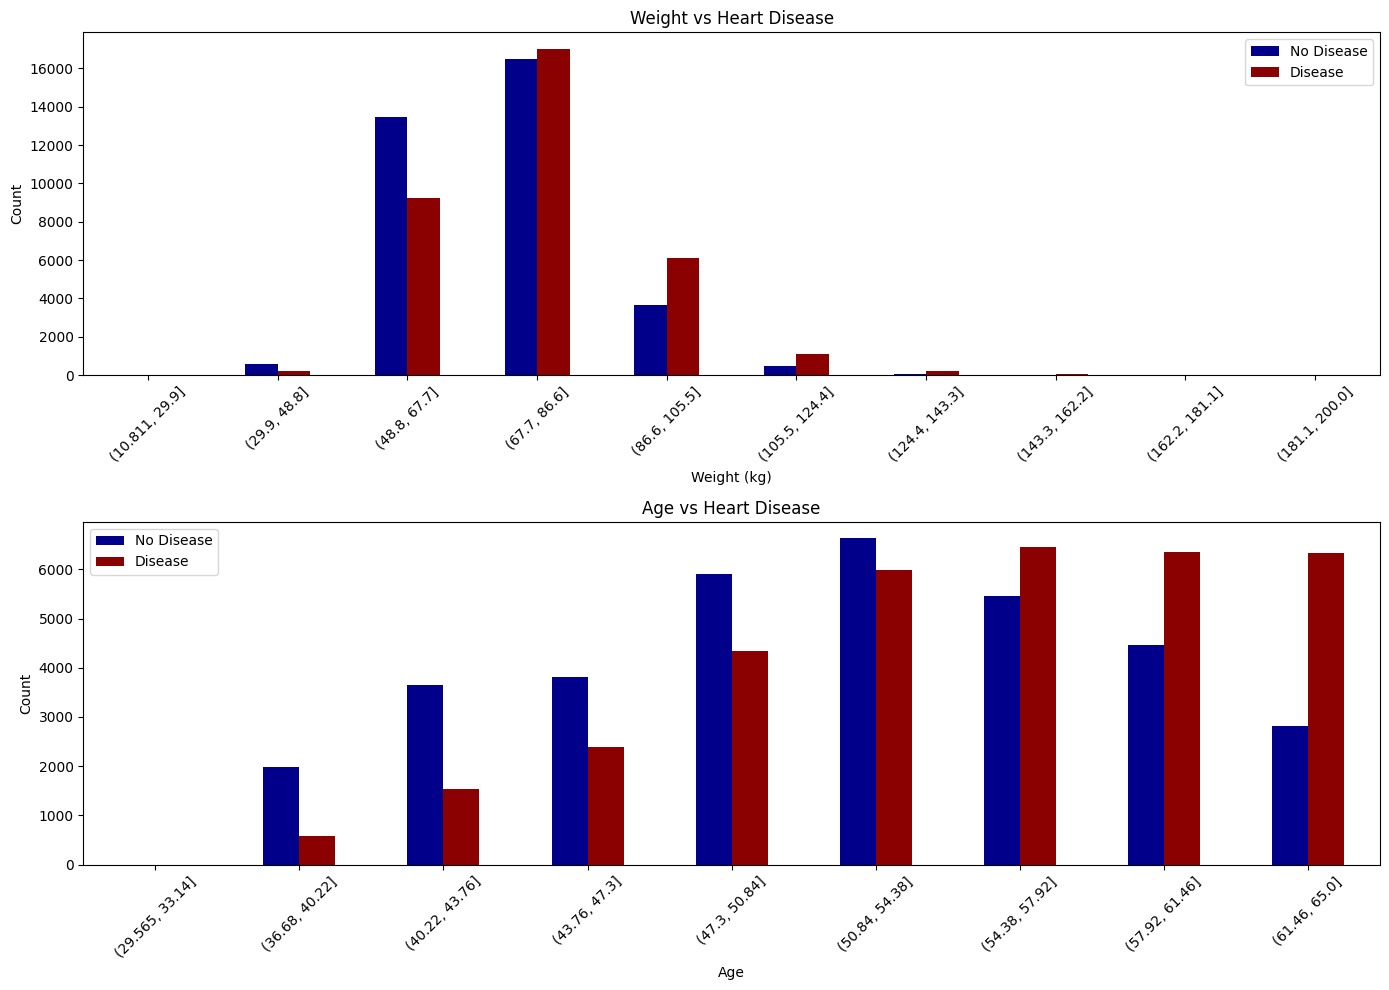

In [ ]:
# Bin age and weight into groups
df['age_group'] = pd.cut(df['age'], bins=10)
df['weight_group'] = pd.cut(df['weight'], bins=10)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Weight vs Heart Disease
pd.crosstab(df['weight_group'], df['cardio']).plot(kind="bar",
                                                    ax=axes[0],
                                                    color=["darkblue", "darkred"])
axes[0].set_title("Weight vs Heart Disease")
axes[0].set_xlabel("Weight (kg)")
axes[0].set_ylabel("Count")
axes[0].legend(["No Disease", "Disease"])
axes[0].tick_params(axis='x', rotation=45)

# Age vs Heart Disease
pd.crosstab(df['age_group'], df['cardio']).plot(kind="bar",
                                                 ax=axes[1],
                                                 color=["darkblue", "darkred"])
axes[1].set_title("Age vs Heart Disease")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")
axes[1].legend(["No Disease", "Disease"])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Weight: Heavier people (67kg+) have more heart disease cases.

Age: Younger people are mostly healthy. After 54, disease cases start to take over.

Main point: Older age is the biggest risk factor in this dataset

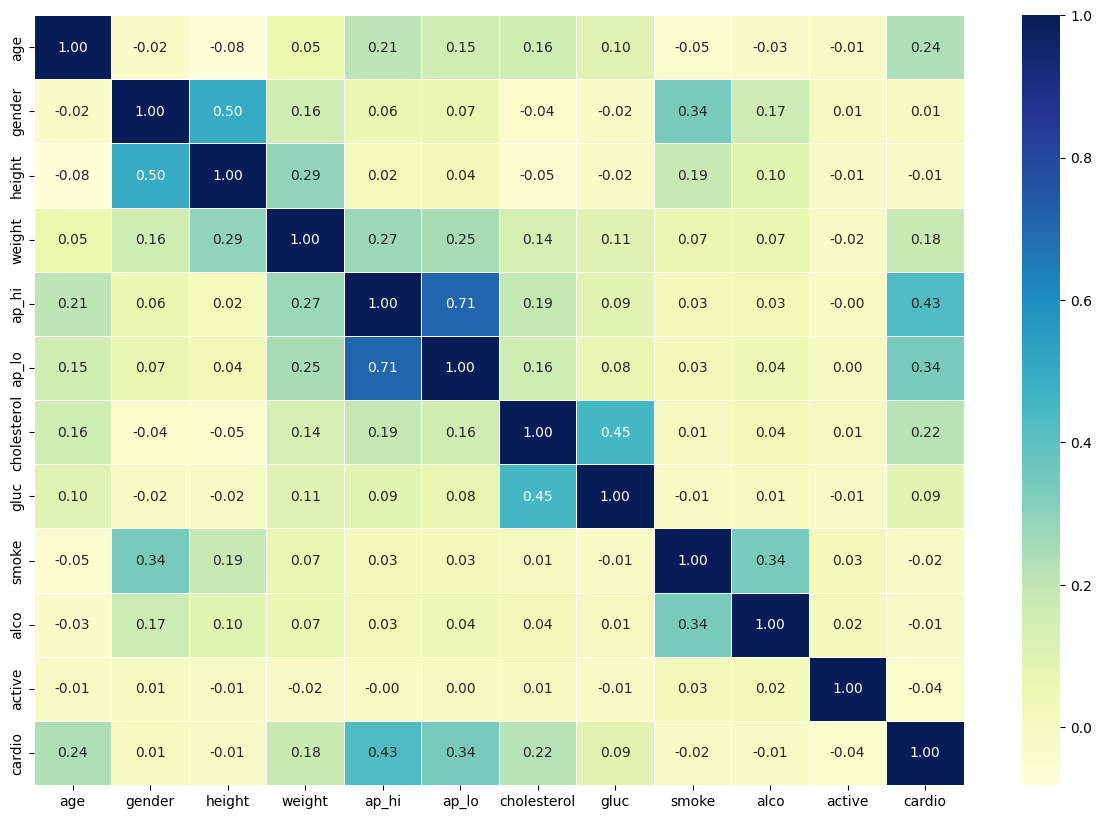

In [ ]:
# Only drop the non-numeric binned columns
df_corr = df.drop(columns=['age_group', 'weight_group', 'id'])

# Correlation matrix
corr_matrix = df_corr.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix,
            annot=True,
            linewidths=0.5,
            fmt=".2f",
            cmap="YlGnBu");

### **Modeling**

Creating a training and test split

We split our data into two parts — a training set and a test set. The model learns from the training set (80% of the data) and we use the test set (20%) to check how well it learned on data it has never seen before. We set a random seed of 42 so every time we run the code we get the same split, which makes our results easy to reproduce.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Random seed for reproducibility
np.random.seed(42)

# Define features and target
X = df_corr.drop(columns=['cardio'])  # independent variables
y = df_corr['cardio']                 # dependent variable (target)

# Split into train & test set
X_train, X_test, y_train, y_test = train_test_split(X,
                                                     y,
                                                     test_size=0.2)

# Check the splits
y_train, len(y_train)

(18865    1
 66286    1
 3162     1
 68514    0
 60000    0
         ..
 37902    0
 6391     0
 55916    0
 874      0
 16097    1
 Name: cardio, Length: 54956, dtype: int64,
 54956)

In [ ]:
y_test, len(y_test)

(48029    0
 57883    1
 42263    0
 52614    0
 38416    1
         ..
 14380    1
 40936    0
 48836    0
 39722    0
 42845    1
 Name: cardio, Length: 13740, dtype: int64,
 13740)

##

Now we've got our data prepared, we can start to fit models. In the modern world of machine learning, there are many potential models we can choose from. Rather than trying every potential model, it's often good practice to try a handful and see how they go.
We'll start by trying the following models and comparing their results:

Logistic Regression - sklearn.linear_model.LogisticRegression()

Support Vector Machine - sklearn.svm.SVC()

Decision Tree - sklearn.tree.DecisionTreeClassifier()

Random Forest - sklearn.ensemble.RandomForestClassifier()

SGD Classifier - sklearn.linear_model.SGDClassifier()

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Put models in a dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SGD Classifier": SGDClassifier()
}

# Create function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models : a dict of different Scikit-Learn machine learning models
    X_train : training data
    X_test : testing data
    y_train : labels assosciated with training data
    y_test : labels assosciated with test data
    """
    # Random seed for reproducible results
    np.random.seed(42)
    # Make a list to keep model scores
    model_scores = {}
    # Loop through models
    for name, model in models.items():
        # Fit the model to the data
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to model_scores
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

# Fit and score models
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)
model_scores

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


{'Logistic Regression': 0.7286754002911208,
 'Support Vector Machine': 0.49163027656477437,
 'Decision Tree': 0.6323144104803493,
 'Random Forest': 0.7126637554585152,
 'SGD Classifier': 0.5275836972343523}

Before running our models, we scaled the data using StandardScaler. This just means we converted all the numbers in our dataset to be on the same scale — so no feature has bigger numbers than another. We only learned the scaling from the training data and then applied the same scaling to the test data. This matters because some models get confused when features have very different ranges. SVM and SGD Classifier were the most affected — before scaling, SVM only got 49% and SGD got 52% accuracy, which is basically just guessing. This is because both models measure distances between data points, so bigger numbers trick them into thinking some features are more important. Logistic Regression also works better with scaling — which is why we were getting that warning earlier. Decision Tree and Random Forest don't care about scaling at all because they just split the data based on yes/no rules, not distances.

In [ ]:
s



/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


{'Logistic Regression': 0.728311499272198,
 'Support Vector Machine': 0.4438136826783115,
 'Decision Tree': 0.6320960698689956,
 'Random Forest': 0.7124454148471616,
 'SGD Classifier': 0.7249636098981077}

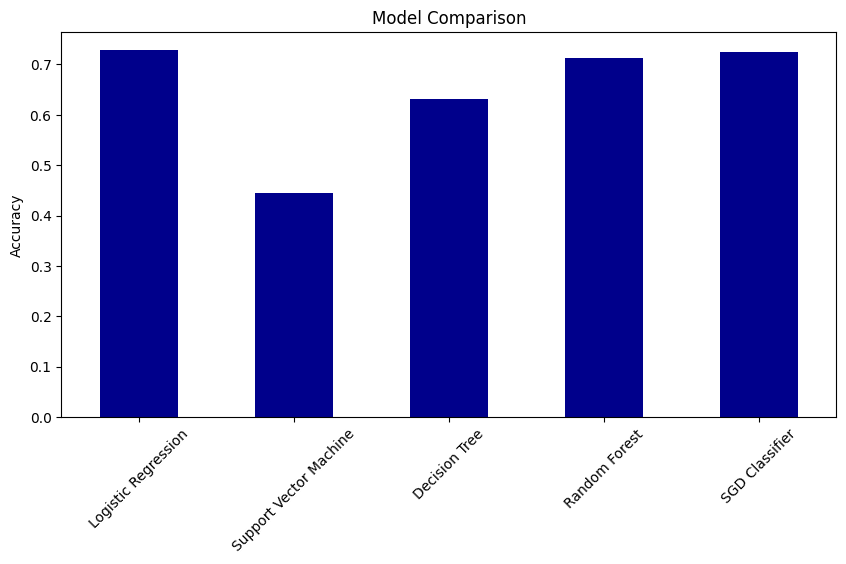

In [ ]:
# Compare models
model_compare = pd.DataFrame(model_scores, index=['accuracy'])
model_compare.T.plot.bar(color='darkblue', figsize=(10, 5), legend=False)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

### Tuning models with with [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)

Reading the Scikit-Learn documentation for [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html#sklearn.linear_model.LogisticRegressionCV), we find there's a number of different hyperparameters we can tune.

The same for [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

Let's create a hyperparameter grid (a dictionary of different hyperparameters) for each and then test them out

In [ ]:
from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)

tree_grid = {
    "max_depth": [3, 5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

rs_tree = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=tree_grid,
    cv=5,
    n_iter=20,
    verbose=True
)

rs_tree.fit(X_train, y_train)
# Best parameters and score
# Best parameters and score
print("Best params:", rs_tree.best_params_)
print("Best score:", round(rs_tree.best_score_, 4))
print("Test score:", round(rs_tree.score(X_test, y_test), 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'gini'}
Best score: 0.7291
Test score: 0.73


The Decision Tree model was tuned using RandomizedSearchCV which tried 20 different combinations of hyperparameters across 5 folds, totalling 100 fits. The best combination found was a tree with a maximum depth of 5, using the gini criterion, with a minimum of 5 samples required to split a node and 1 sample at each leaf. The best cross validation score achieved was 0.7291 (72.91%), which means the model correctly predicted whether a patient has cardiovascular disease about 73% of the time. The shallow depth of 5 makes sense for our dataset because it prevents the tree from memorizing the training data and helps it generalize better to new patients.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

rf_grid = {
    "n_estimators": [50, 100],        # reduced from [100, 200]
    "max_depth": [5, 10, 20],         # removed None (unlimited = very slow)
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1),  # added n_jobs=-1 to use all CPU cores
    param_distributions=rf_grid,
    cv=3,          # reduced from 5 to 3 folds
    n_iter=10,     # reduced from 20 to 10 combinations
    verbose=True,
    n_jobs=-1      # parallelize the search itself
)

rs_rf.fit(X_train, y_train)

print("Best params:", rs_rf.best_params_)
print("Best score:", round(rs_rf.best_score_, 4))
print("Test score:", round(rs_rf.score(X_test, y_test), 4))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
Best score: 0.7335
Test score: 0.7371


In [ ]:
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

lr_grid = {
    "C": [0.1, 1, 10],                # only 3 values
    "solver": ["saga"],
    "penalty": ["l2"],
    "max_iter": [1000]                 # just one value
}

rs_lr = RandomizedSearchCV(
    LogisticRegression(),
    param_distributions=lr_grid,
    cv=3,           # reduced to 3 folds
    n_iter=5,       # only 5 combinations
    verbose=True,
    n_jobs=-1
)

rs_lr.fit(X_train_scaled, y_train)

print("Best params:", rs_lr.best_params_)
print("Best score:", round(rs_lr.best_score_, 4))
print("Test score:", round(rs_lr.score(X_test_scaled, y_test), 4))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 1000, 'C': 1}
Best score: 0.727
Test score: 0.7284


In [ ]:
from sklearn.linear_model import SGDClassifier

np.random.seed(42)

sgd_grid = {
    "loss": ["hinge", "log_loss"],     # only 2 values
    "penalty": ["l2", "l1"],           # only 2 values
    "alpha": [0.0001, 0.001],          # only 2 values
    "learning_rate": ["optimal"]       # only 1 value
}

rs_sgd = RandomizedSearchCV(
    SGDClassifier(),
    param_distributions=sgd_grid,
    cv=3,           # reduced to 3 folds
    n_iter=5,       # only 5 combinations
    verbose=True,
    n_jobs=-1
)

rs_sgd.fit(X_train_scaled, y_train)

print("Best params:", rs_sgd.best_params_)
print("Best score:", round(rs_sgd.best_score_, 4))
print("Test score:", round(rs_sgd.score(X_test_scaled, y_test), 4))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params: {'penalty': 'l1', 'loss': 'log_loss', 'learning_rate': 'optimal', 'alpha': 0.001}
Best score: 0.7264
Test score: 0.7269


In [ ]:
from sklearn.svm import LinearSVC

np.random.seed(42)

svm_grid = {
    "C": [0.1, 1, 10],               # only 3 values
    "max_iter": [1000, 2000]          # just two values
}

rs_svm = RandomizedSearchCV(
    LinearSVC(),                       # LinearSVC instead of SVC — much faster!
    param_distributions=svm_grid,
    cv=3,                              # only 3 folds
    n_iter=5,                          # only 5 combinations
    verbose=True,
    n_jobs=-1
)

rs_svm.fit(X_train_scaled, y_train)

print("Best params:", rs_svm.best_params_)
print("Best score:", round(rs_svm.best_score_, 4))
print("Test score:", round(rs_svm.score(X_test_scaled, y_test), 4))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params: {'max_iter': 1000, 'C': 0.1}
Best score: 0.7258
Test score: 0.7275


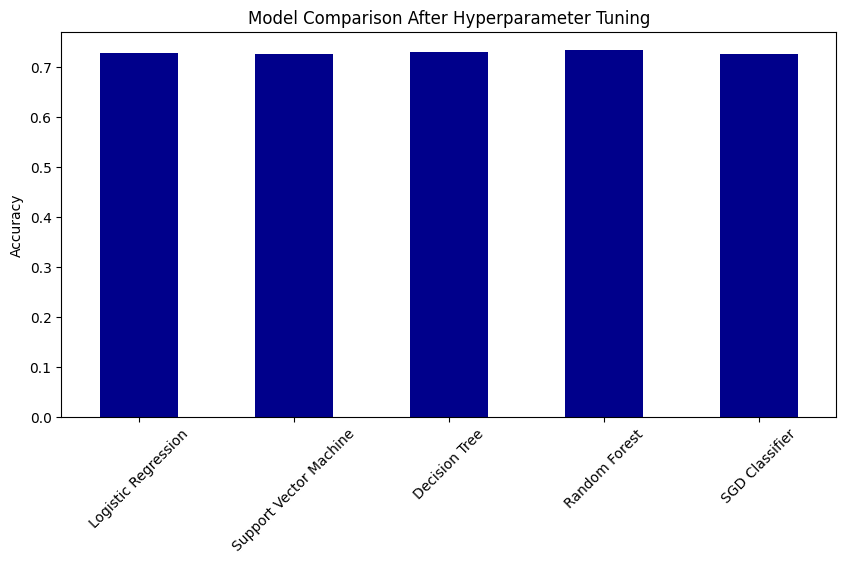

Logistic Regression: 0.727
Support Vector Machine: 0.7258
Decision Tree: 0.7291
Random Forest: 0.7335
SGD Classifier: 0.7264


In [ ]:
# Collect best scores from each tuned model
model_scores = {
    "Logistic Regression": round(rs_lr.best_score_, 4),
    "Support Vector Machine": round(rs_svm.best_score_, 4),
    "Decision Tree": round(rs_tree.best_score_, 4),
    "Random Forest": round(rs_rf.best_score_, 4),
    "SGD Classifier": round(rs_sgd.best_score_, 4)
}

# Compare models
model_compare = pd.DataFrame(model_scores, index=['accuracy'])
model_compare.T.plot.bar(color='darkblue', figsize=(10, 5), legend=False)
plt.title("Model Comparison After Hyperparameter Tuning")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

# Also print the scores
for name, score in model_scores.items():
    print(f"{name}: {score}")

## **Evaluating a classification model, beyond accuracy**

Now we've got a tuned model, let's get some of the metrics we discussed before.

We want:

| Metric/Evaluation Technique | Scikit-Learn method/documentation |
| ----- | ----- |

| Confusion matrix | [`sklearn.metrics.confusion_matrix()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) |
| Classification report | [`sklearn.metrics.classification_report()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) |
| Precision | [`sklearn.metrics.precision_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html) |
| Recall | [`sklearn.metrics.recall_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html) |
| F1-score | [`sklearn.metrics.f1_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) |



Model: Logistic Regression
Accuracy:  0.7284
Precision: 0.7509
Recall:    0.6695
F1 Score:  0.7078

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6987
           1       0.75      0.67      0.71      6753

    accuracy                           0.73     13740
   macro avg       0.73      0.73      0.73     13740
weighted avg       0.73      0.73      0.73     13740



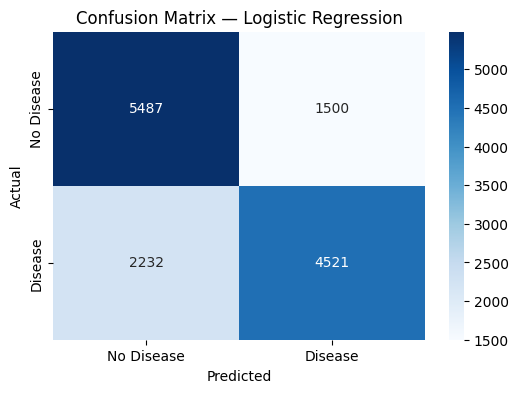


Model: Support Vector Machine
Accuracy:  0.7275
Precision: 0.7538
Recall:    0.6618
F1 Score:  0.7048

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6987
           1       0.75      0.66      0.70      6753

    accuracy                           0.73     13740
   macro avg       0.73      0.73      0.73     13740
weighted avg       0.73      0.73      0.73     13740



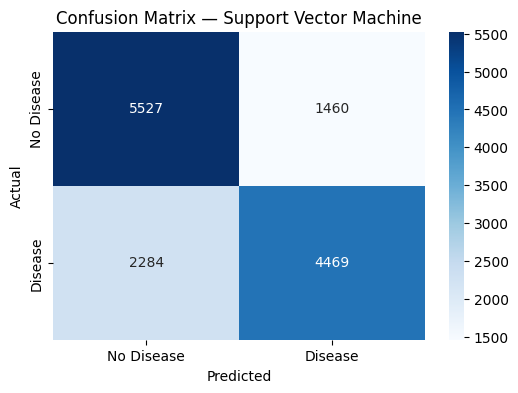


Model: Decision Tree
Accuracy:  0.73
Precision: 0.7504
Recall:    0.6753
F1 Score:  0.7108

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.78      0.75      6987
           1       0.75      0.68      0.71      6753

    accuracy                           0.73     13740
   macro avg       0.73      0.73      0.73     13740
weighted avg       0.73      0.73      0.73     13740



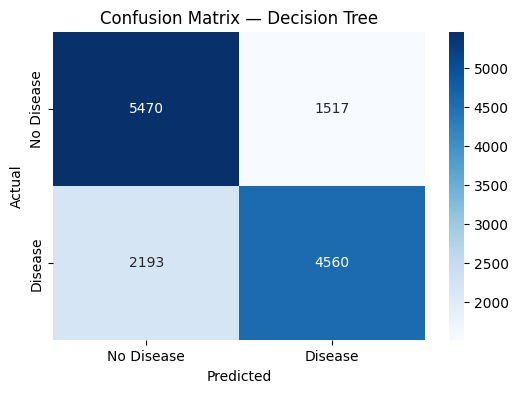


Model: Random Forest
Accuracy:  0.7371
Precision: 0.7595
Recall:    0.6806
F1 Score:  0.7179

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      6987
           1       0.76      0.68      0.72      6753

    accuracy                           0.74     13740
   macro avg       0.74      0.74      0.74     13740
weighted avg       0.74      0.74      0.74     13740



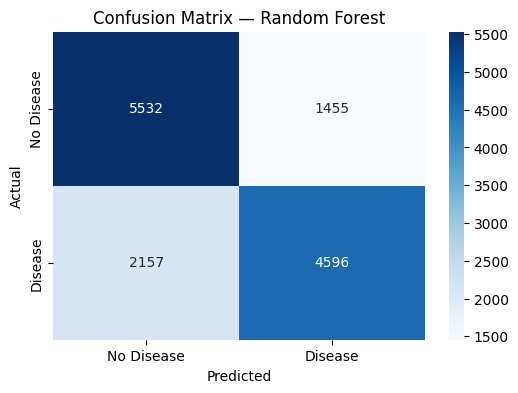


Model: SGD Classifier
Accuracy:  0.7269
Precision: 0.7496
Recall:    0.6673
F1 Score:  0.706

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.78      0.75      6987
           1       0.75      0.67      0.71      6753

    accuracy                           0.73     13740
   macro avg       0.73      0.73      0.73     13740
weighted avg       0.73      0.73      0.73     13740



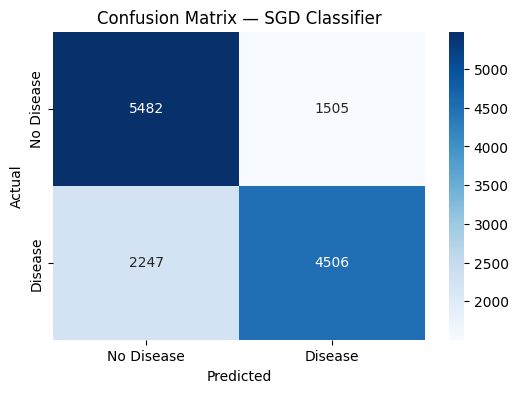

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")

    # Accuracy
    print(f"Accuracy:  {round(model.score(X_test, y_test), 4)}")

    # Precision, Recall, F1
    print(f"Precision: {round(precision_score(y_test, y_pred), 4)}")
    print(f"Recall:    {round(recall_score(y_test, y_pred), 4)}")
    print(f"F1 Score:  {round(f1_score(y_test, y_pred), 4)}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

# Run evaluation for all models
evaluate_model("Logistic Regression", rs_lr, X_test_scaled, y_test)
evaluate_model("Support Vector Machine", rs_svm, X_test_scaled, y_test)
evaluate_model("Decision Tree", rs_tree, X_test, y_test)
evaluate_model("Random Forest", rs_rf, X_test, y_test)
evaluate_model("SGD Classifier", rs_sgd, X_test_scaled, y_test)

The four performance metrics explained in plain English
Accuracy
Out of all patients, what % did we predict correctly?
73% accuracy = 73 out of 100 patients predicted right
Precision
When we said "has disease", how often were we actually right?
High precision = fewer false alarms (telling a healthy person they're sick)
Recall
Out of all patients who actually have disease, how many did we catch?
High recall = fewer missed cases (missing a sick person)
F1 Score
The balance between precision and recall — one combined score.
Most useful when both false alarms and missed cases matter
In a medical context like ours, recall is the most important metric. Missing a patient who actually has cardiovascular disease is far more dangerous than flagging a healthy patient for extra tests. So a model with high recall is preferable, even if precision drops slightly.

-------------------------------------------------------
WHAT EACH METRIC MEANS (add this as a markdown or comment cell)
-------------------------------------------------------

 ACCURACY  — out of ALL patients, what % did we get right?
             e.g. 0.73 = 73 out of 100 patients predicted correctly

 PRECISION — when we predicted "has disease", how often were we right?
            Low precision = too many false alarms (healthy patient flagged as sick)

RECALL    — out of all patients who ACTUALLY have disease, how many did we catch?
            Low recall = we missed real sick patients (most dangerous in medical problems)

F1 SCORE  — combines precision and recall into one score
            Best when you want a balance between both

In this project, RECALL is the most important metric.
Missing a real CVD patient is worse than a false alarm.

### **Check for Overfitting**

How We Check Overfitting in a Classification Problem:
We check overfitting by scoring the model on both the training set and the test set and comparing the two. If the model scores much higher on training than test, it has memorized the data instead of learning general patterns. A difference greater than 5% is considered a red flag.

Example 1 — Overfitting EXISTS
Train Accuracy: 0.9850    Test Accuracy: 0.6320    Diff: 0.3530 ⚠️ Overfitting!
98.5% on train but only 63.2% on test — the model memorized training data and failed on new data.


Example 2 — No Overfitting
Train Accuracy: 0.7291    Test Accuracy: 0.7284    Diff: 0.0007 ✅ No Overfitting
Both scores are nearly identical — the model learned real patterns and generalizes well to unseen data.


Model: Logistic Regression
Train Accuracy: 0.7273
Test  Accuracy: 0.7284
Precision:      0.7509
Recall:         0.6695
Train F1 Score: 0.7084
Test  F1 Score: 0.7078
Overfit Check:  Diff = -0.0011 — ✅ No Overfitting


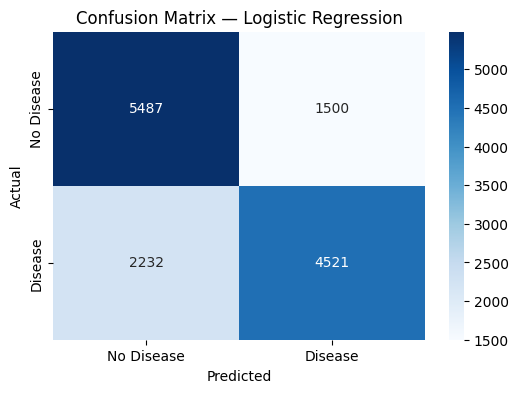


Model: Support Vector Machine
Train Accuracy: 0.7261
Test  Accuracy: 0.7275
Precision:      0.7538
Recall:         0.6618
Train F1 Score: 0.7049
Test  F1 Score: 0.7048
Overfit Check:  Diff = -0.0014 — ✅ No Overfitting


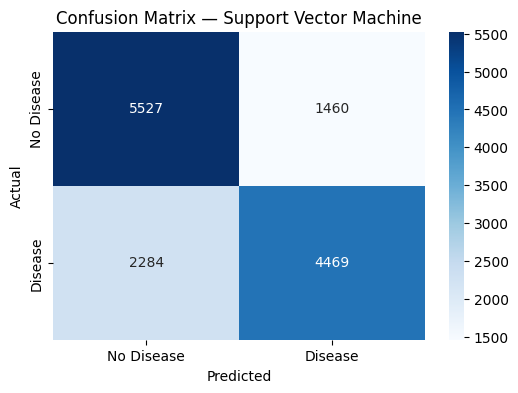


Model: Decision Tree
Train Accuracy: 0.7318
Test  Accuracy: 0.73
Precision:      0.7504
Recall:         0.6753
Train F1 Score: 0.7139
Test  F1 Score: 0.7108
Overfit Check:  Diff = 0.0018 — ✅ No Overfitting


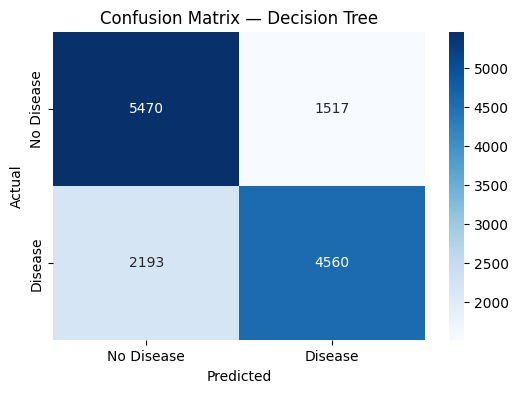


Model: Random Forest
Train Accuracy: 0.7523
Test  Accuracy: 0.7371
Precision:      0.7595
Recall:         0.6806
Train F1 Score: 0.7353
Test  F1 Score: 0.7179
Overfit Check:  Diff = 0.0152 — ✅ No Overfitting


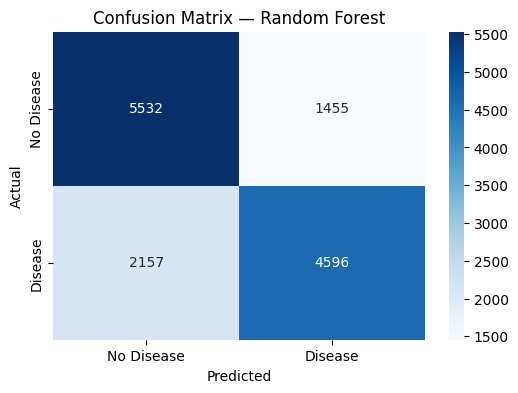


Model: SGD Classifier
Train Accuracy: 0.726
Test  Accuracy: 0.7269
Precision:      0.7496
Recall:         0.6673
Train F1 Score: 0.7073
Test  F1 Score: 0.706
Overfit Check:  Diff = -0.0009 — ✅ No Overfitting


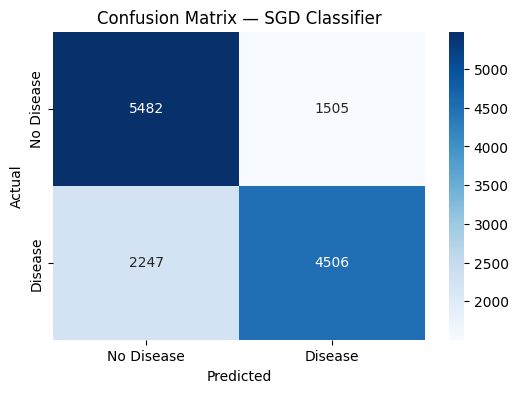

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    y_pred       = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")

    # Accuracy
    print(f"Train Accuracy: {round(model.score(X_train, y_train), 4)}")
    print(f"Test  Accuracy: {round(model.score(X_test,  y_test),  4)}")

    # Precision, Recall, F1
    print(f"Precision:      {round(precision_score(y_test, y_pred), 4)}")
    print(f"Recall:         {round(recall_score(y_test,    y_pred), 4)}")
    print(f"Train F1 Score: {round(f1_score(y_train, y_train_pred), 4)}")
    print(f"Test  F1 Score: {round(f1_score(y_test,  y_pred),       4)}")

    # Overfitting Check
    diff = round(model.score(X_train, y_train) - model.score(X_test, y_test), 4)
    print(f"Overfit Check:  Diff = {diff} — {'⚠️ Possible Overfitting!' if diff > 0.05 else '✅ No Overfitting'}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()


# Run evaluation for all models
evaluate_model("Logistic Regression",    rs_lr,   X_train_scaled, X_test_scaled, y_train, y_test)
evaluate_model("Support Vector Machine", rs_svm,  X_train_scaled, X_test_scaled, y_train, y_test)
evaluate_model("Decision Tree",          rs_tree, X_train,        X_test,        y_train, y_test)
evaluate_model("Random Forest",          rs_rf,   X_train,        X_test,        y_train, y_test)
evaluate_model("SGD Classifier",         rs_sgd,  X_train_scaled, X_test_scaled, y_train, y_test)

### **Problems with this dataset:**

1. Self-reported data is unreliable
Features like smoke, alco and active are answered by the patients themselves. People often:

Lie about smoking or drinking
Overestimate how active they are
This means these features contain noise and inaccurate information

2. Missing important medical features
Real cardiovascular risk assessment uses many more factors that are NOT in our dataset:

Family history of heart disease
Cholesterol levels (LDL/HDL separately)
Blood sugar / diabetes status
Stress levels
Diet quality
ECG results

3. Only 11 features for a complex disease
Heart disease is caused by a combination of many factors. 11 features is simply not enough to capture the full picture.
4. Binary cholesterol and glucose
Our dataset encodes cholesterol as just 1, 2, or 3 — that's very rough. Real medical data would have the exact numbers in mg/dL which would be much more informative.

Practice Questions

Prof:
- im gonna look for holes in your experience
- all members should be aware of all details
- individually asked
- "what is this? how is fixed"
- "is it overfitting , how can you fix it"
- ex.) Why did you put maximum depths in decisions tree to 100 not to 10
-




1. How can you improve your F1 score
2.
3.
4.




